In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

/home/kamadahanam/Documents/ALL_WORKS/Programming/LangChain/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv('../.env')

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class blogState(TypedDict):

    title:str
    outline:str
    content:str

In [5]:
def get_outline(State: blogState):

    title=State['title']

    prompt=f"Give a list of structured and nested headings and subheading on the topic {title}"

    outline=model.invoke(prompt).content

    if not isinstance(outline, str):
        raise TypeError("Expected model response content to be a string")

    State['outline']=outline

    return State

In [6]:
def get_content(State: blogState):

    outline = State['outline']
    title = State['title']

    prompt = f"Write a blog using the following structure on the topic {title} \n {outline}"

    content = model.invoke(prompt).content

    if not isinstance(content, str):
        raise TypeError("Expected model response content to be a string")

    State['content'] = content

    return State

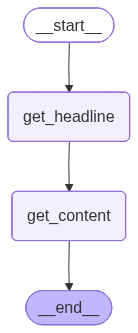

In [9]:
graph = StateGraph(blogState)

graph.add_node('get_headline',get_outline)
graph.add_node('get_content',get_content)

graph.add_edge(START, 'get_headline')
graph.add_edge('get_headline','get_content')
graph.add_edge('get_content',END)

workflow=graph.compile()
workflow

In [10]:
initial_state = {'title':'Why AI animated content, even after improvising so much, still loks like ai based?'}

final_state=workflow.invoke(initial_state)

In [11]:
final_state['outline']

'Here\'s a structured and nested list of headings and subheadings exploring why AI-animated content, despite significant improvements, still often looks distinctly "AI-generated":\n\n---\n\n**Why AI Animated Content Still Looks Like AI: Unpacking the Persistent "AI Look"**\n\n**I. Introduction: The Paradox of Progress in AI Animation**\n    A. Rapid Advancements vs. Persistent Identifiable Markers\n        1. Exponential growth in generative AI capabilities (diffusion models, LLMs for scripting)\n        2. The enduring "AI look" despite high fidelity and detail\n    B. Defining "The AI Look" in Animation\n        1. Subtle visual inconsistencies and temporal instability\n        2. Unnatural movement, physics, and character performance\n        3. Lack of nuanced expression, emotional depth, and intentional artistry\n\n**II. Technical & Algorithmic Limitations**\n    A. Core Generative AI Challenges\n        1. **Temporal Coherence and Consistency:**\n            a. Difficulty maintai

In [12]:
final_state['content']

'## Why AI Animated Content Still Looks Like AI: Unpacking the Persistent "AI Look"\n\nIn the blink of an eye, AI has gone from generating quirky images to crafting elaborate, seemingly seamless video content. We\'ve seen incredible advancements – photorealistic details, complex movements, and even AI-driven storytelling. Yet, despite this exponential growth, there\'s often an unmistakable quality that screams, "This was made by AI." It\'s the "AI look," and it persists even in the most sophisticated productions.\n\nSo, why does AI-animated content, even after improvising so much, still look distinctly artificial? Let\'s dive into the fascinating paradox of progress in AI animation.\n\n### I. Introduction: The Paradox of Progress in AI Animation\n\n**A. Rapid Advancements vs. Persistent Identifiable Markers**\n\nIt’s truly astounding. Just a few years ago, AI-generated video was a glitchy mess of morphing blobs. Today, diffusion models can conjure entire scenes, and large language mode